In [1]:
import joblib
from analysis_utils import *
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

# Virtualization Settings
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# --- 1. Upload Data ---
df = pd.read_csv("../datasets/drug200.csv")
print(f"1. Data is loaded. Size: {df.shape}")

1. Data is loaded. Size: (200, 6)


In [3]:
# --- 1.2. General Structure ---
check_general_structure(df)

=== Data Types and Non-Null Information ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 12.5 KB
None

=== Missing Value Summary ===
Empty DataFrame
Columns: [Missing Count, Missing Percentage (%)]
Index: []


,Missing Count,Missing Percentage (%)
Age,0,0.0
Sex,0,0.0
BP,0,0.0
Cholesterol,0,0.0
Na_to_K,0,0.0
Drug,0,0.0


--- Numerical Column Distributions ---


/tmp/ipykernel_100240/3415621950.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=["object", "category"])


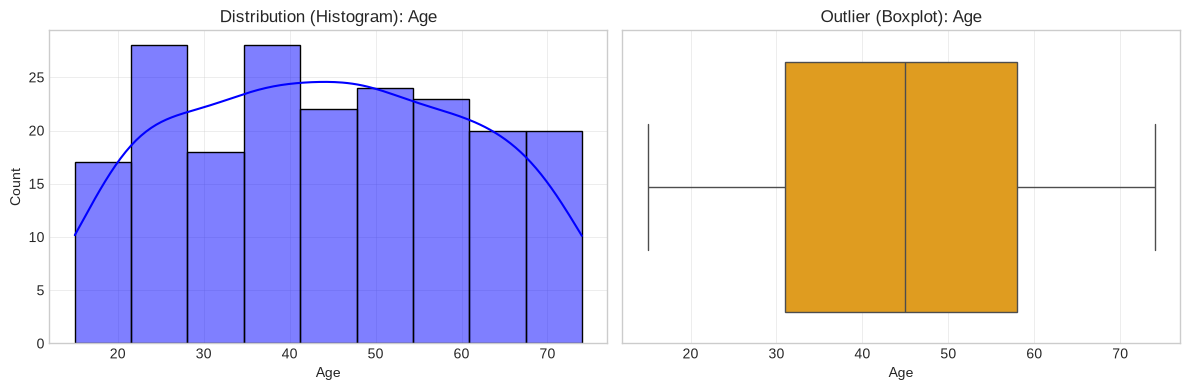

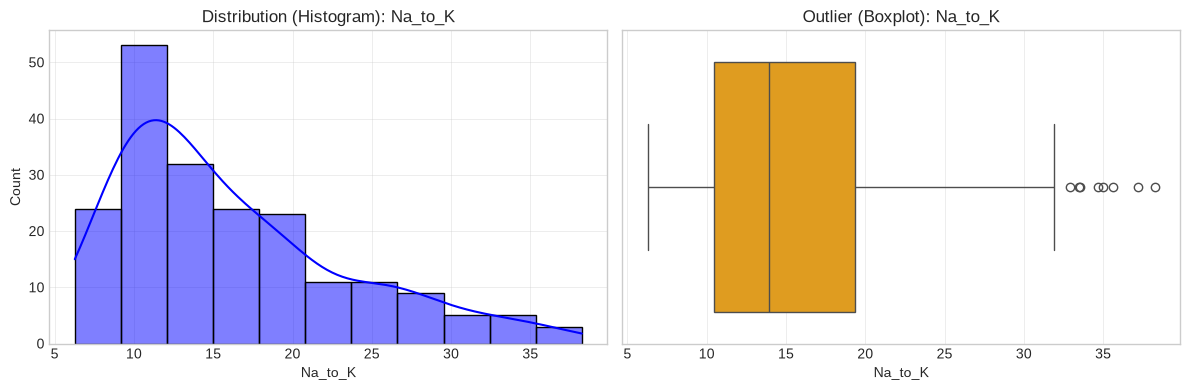

--- Categorical Column Distributions ---


/home/gokay/PycharmProjects/FastApiProject/data_analysis/analysis_utils.py:333: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/home/gokay/PycharmProjects/FastApiProject/data_analysis/analysis_utils.py:333: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/home/gokay/PycharmProjects/FastApiProject/data_analysis/analysis_utils.py:333: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


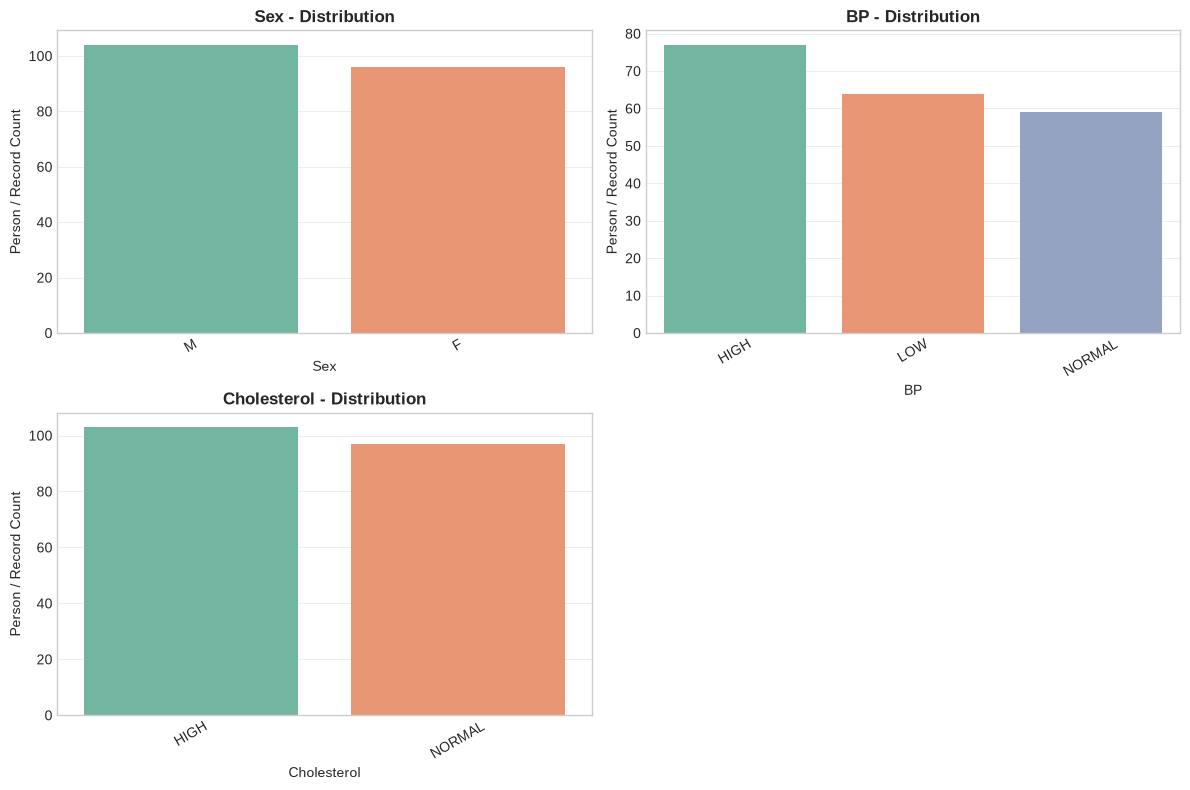

In [4]:
# --- 2.1 Statistical Distributions ---
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

categorical_cols = (
    df.select_dtypes(include=["object", "category"])
    .columns.drop("Drug", errors="ignore")
    .tolist()
)
# Numerical Distributions
print("--- Numerical Column Distributions ---")
plot_statistical_distributions(df, numeric_cols)

# Categorical Distributions
print("--- Categorical Column Distributions ---")
plot_categorical_distributions(df, categorical_cols)

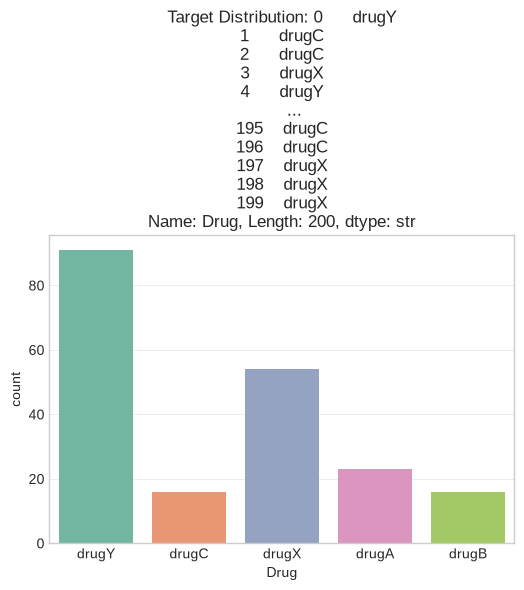

In [5]:
# --- 3. Target Distribution ---
target_column = df["Drug"]
plot_target_distribution(df, target_column)

Detected numerical columns: ['Age', 'Na_to_K']
Detected categorical (string) columns: ['Sex', 'BP', 'Cholesterol']
--- Statistical Feature Importance Analysis (Mutual Information) ---
              Feature  MI_Score
1             Na_to_K  0.707131
4           BP_NORMAL  0.244899
3              BP_LOW  0.169665
5  Cholesterol_NORMAL  0.098652
0                 Age  0.074204
2               Sex_M  0.000000


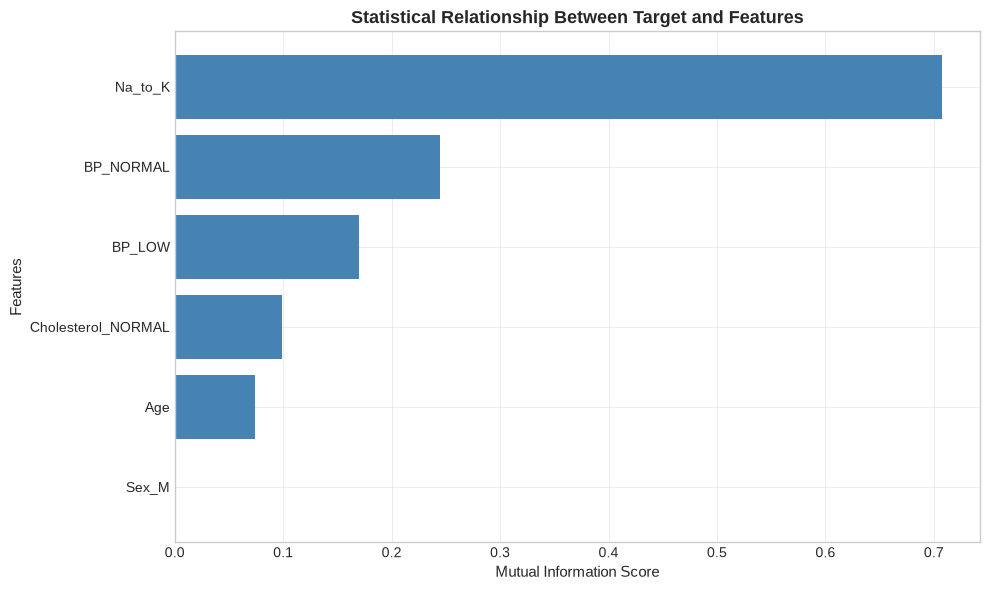

Detected numerical columns: ['Age', 'Na_to_K']
Detected categorical (string) columns: ['Sex', 'BP', 'Cholesterol']
--- Mixed/Categorical Feature Relationship Scores (Mutual Information) ---
Na_to_K               0.707131
BP_NORMAL             0.244899
BP_LOW                0.169665
Cholesterol_NORMAL    0.098652
Age                   0.074204
Sex_M                 0.000000
dtype: float64
Low-score columns that can be dropped: ['Sex_M']


In [6]:
# --- 4. Feature Correlations Analyze ---
mi_results = calculate_and_plot_mutual_information(df, target_col="Drug")
target_corr, to_drop = analyze_mixed_feature_relations(df, target_col="Drug")

In [7]:
# --- 4.2 Encoding Categorical Columns ---
encoders = {}
for col in categorical_cols:
  encoder = OrdinalEncoder(
      handle_unknown="use_encoded_value", unknown_value=-1
  )
  df[col] = encoder.fit_transform(df[[col]])
  encoders[col] = encoder

In [8]:
# --- 4.3 Feature Correlations Analyze
target_corr, to_drop = analyze_mixed_feature_relations(df, target_col="Drug")

Detected numerical columns: ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
Detected categorical (string) columns: []
--- Mixed/Categorical Feature Relationship Scores (Mutual Information) ---
Na_to_K        0.707131
BP             0.407825
Age            0.080361
Cholesterol    0.059260
Sex            0.001743
dtype: float64
Low-score columns that can be dropped: ['Sex']


In [9]:
# --- 5. Train - Test Split ---
X = df.drop(columns=["Drug", "Sex"])
y = df["Drug"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n5. Data is Splitted -> Train: {X_train.shape}, Test: {X_test.shape}")


5. Data is Splitted -> Train: (160, 4), Test: (40, 4)


In [10]:
# --- 6. Correlation Filter ---
X_train_corr, X_test_corr = correlation_filter(
    X_train, X_test, corr_threshold=0.95
)

9. Remaining Feature Count After Correlation Filter: 4


In [11]:
# --- 7. Clearing Constant Columns ---
constant_cols = [
    col for col in X_train_corr.columns if X_train_corr[col].nunique() == 0
]

if constant_cols:
  print(f"Detected Constant Columns: {constant_cols}")
  X_train_corr = X_train_corr.drop(columns=constant_cols)
  X_test_corr = X_test_corr.drop(columns=constant_cols)
else:
  print("No Constant Columns Detected.")

No Constant Columns Detected.


In [12]:
# --- 8. Feature Selection ---
selected_features = select_best_features_anova_string(X_train_corr, y_train)
X_train_selected = X_train_corr[selected_features]
X_test_selected = X_test_corr[selected_features]

=== Top 4 Features (ANOVA) ===
       Feature      Score
3      Na_to_K  73.250077
1           BP  36.554354
0          Age   6.126107
2  Cholesterol   4.250151


In [13]:
# All in Bundle
bundle = {
    "X_train": X_train_selected,
    "X_test": X_test_selected,
    "y_train": y_train,
    "y_test": y_test,
}
joblib.dump(bundle, "../backend/models/drug/drug_data_bundle.pkl")
joblib.dump(encoders, "../backend/models/drug/encoders_dict.pkl")
joblib.dump(categorical_cols, "../backend/models/drug/categorical_cols.pkl")
print(
    "Processed drug dataset is successfully loaded to: backend/models/drug/"
)

Processed drug dataset is successfully loaded to: backend/models/drug/
